# Chapter 262 — Entropy and Information
### Part VIII: Probability — Advanced Experiments

Shannon entropy quantifies uncertainty. A fair coin (p=0.5) has maximum entropy — you learn the most from its flip. A biased coin (p=0.99) has near-zero entropy — you already know the outcome. This connection between probability and information underpins data compression, machine learning loss functions, and hypothesis testing.

**Prerequisites:** Probability Distributions (ch248), Expected Value (ch249), Probability Rules (ch244), Logarithms (ch072 — Part III).

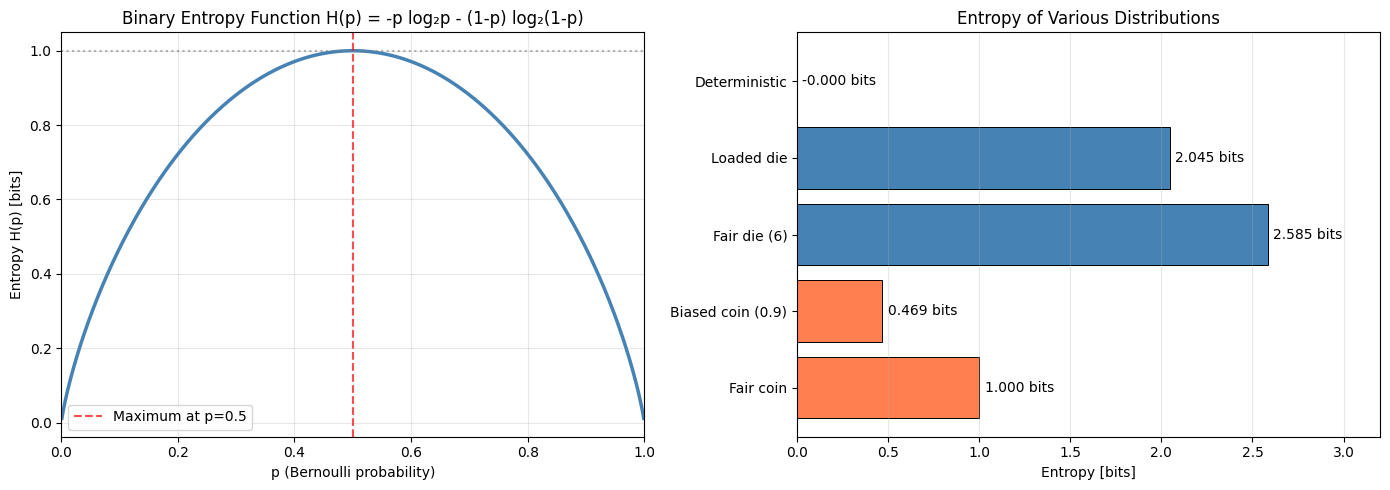

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.special import entr

rng = np.random.default_rng(42)

## 1. Shannon Entropy
# H(X) = -sum_x p(x) log2 p(x)
# Convention: 0 * log(0) = 0

def shannon_entropy(probs, base=2):
    """Compute Shannon entropy of a discrete distribution.
    
    Args:
        probs: array of probabilities (must sum to 1)
        base: logarithm base (2 = bits, e = nats)
    
    Returns:
        entropy in the specified units
    """
    probs = np.asarray(probs, dtype=float)
    probs = probs[probs > 0]  # drop zeros (0 log 0 = 0 by convention)
    return -np.sum(probs * np.log(probs)) / np.log(base)

# Entropy as a function of Bernoulli parameter p
p_values = np.linspace(0.001, 0.999, 500)
entropies = [shannon_entropy([p, 1-p]) for p in p_values]

# Maximum entropy distributions for different supports
examples = [
    ('Fair coin', [0.5, 0.5]),
    ('Biased coin (0.9)', [0.9, 0.1]),
    ('Fair die (6)', [1/6]*6),
    ('Loaded die', [0.4, 0.3, 0.15, 0.1, 0.04, 0.01]),
    ('Deterministic', [1.0, 0.0, 0.0, 0.0]),
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(p_values, entropies, 'steelblue', linewidth=2.5)
axes[0].axvline(0.5, color='red', linestyle='--', alpha=0.7, label='Maximum at p=0.5')
axes[0].axhline(1.0, color='gray', linestyle=':', alpha=0.6)
axes[0].set_xlabel('p (Bernoulli probability)')
axes[0].set_ylabel('Entropy H(p) [bits]')
axes[0].set_title('Binary Entropy Function H(p) = -p log₂p - (1-p) log₂(1-p)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim(0, 1)

names = [e[0] for e in examples]
ents = [shannon_entropy(e[1]) for e in examples]
colors = ['steelblue' if e >= 1.5 else 'coral' for e in ents]
axes[1].barh(names, ents, color=colors, edgecolor='black', linewidth=0.7)
for i, (name, e) in enumerate(zip(names, ents)):
    axes[1].text(e + 0.03, i, f'{e:.3f} bits', va='center')
axes[1].set_xlabel('Entropy [bits]')
axes[1].set_title('Entropy of Various Distributions')
axes[1].grid(True, alpha=0.3, axis='x')
axes[1].set_xlim(0, 3.2)

plt.tight_layout()
plt.savefig('entropy_examples.png', dpi=120, bbox_inches='tight')
plt.show()

## 2. Cross-Entropy and KL Divergence

**Cross-entropy** $H(p, q) = -\sum_x p(x)\log q(x)$ measures the expected code length when encoding $p$-distributed symbols with a $q$-optimal code.

**KL divergence** $D_{KL}(p \| q) = H(p, q) - H(p) = \sum_x p(x)\log\frac{p(x)}{q(x)} \geq 0$

KL is the extra bits from using $q$ when $p$ is the truth. It is not symmetric: $D_{KL}(p\|q) \neq D_{KL}(q\|p)$.

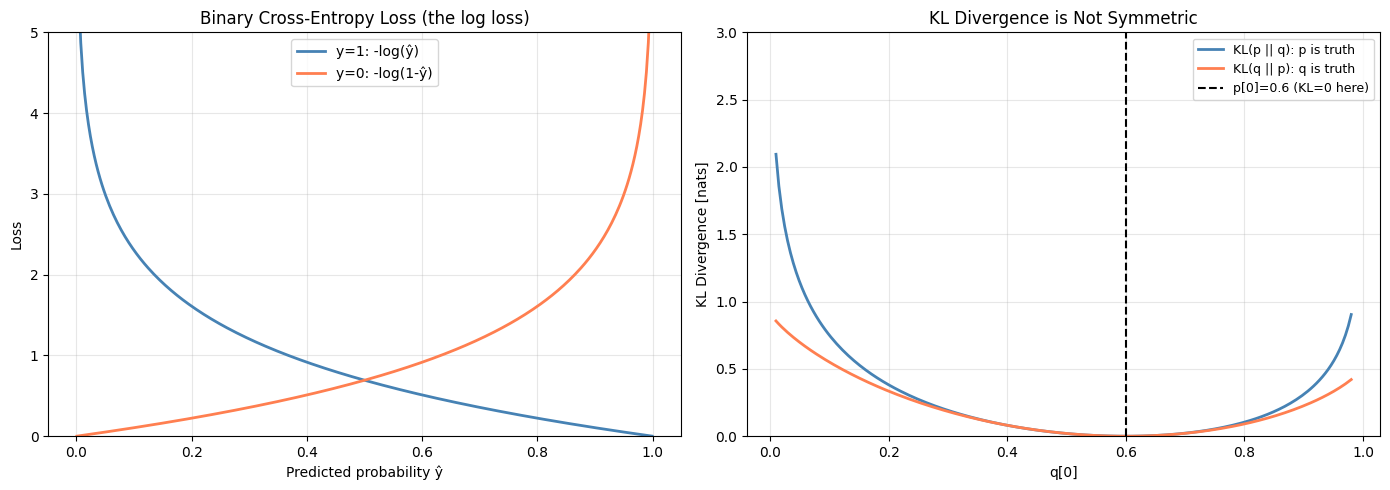

Verification: H(p) + KL(p||q) = CE(p,q)
  H(p)          = 0.897946 nats
  KL(p||q)      = 0.040078 nats
  H(p) + KL     = 0.938024 nats
  CE(p, q)      = 0.938024 nats
  Match: True


In [2]:
def kl_divergence(p, q, eps=1e-12):
    """KL divergence D_KL(p || q).
    
    Args:
        p: true distribution array (must sum to 1)
        q: approximate distribution array (must sum to 1)
        eps: small constant to avoid log(0)
    
    Returns:
        KL divergence in nats
    """
    p = np.asarray(p, dtype=float) + eps
    q = np.asarray(q, dtype=float) + eps
    p = p / p.sum()
    q = q / q.sum()
    return np.sum(p * np.log(p / q))

def cross_entropy(p, q, eps=1e-12):
    """Cross-entropy H(p, q) = -sum p(x) log q(x)."""
    p = np.asarray(p, dtype=float)
    q = np.asarray(q, dtype=float) + eps
    p = p / p.sum()
    q = q / q.sum()
    return -np.sum(p * np.log(q))

# Cross-entropy as ML loss: true labels vs predicted probabilities
# For binary classification: H(y, y_hat) = -y log(y_hat) - (1-y) log(1-y_hat)

y_hat_range = np.linspace(0.001, 0.999, 300)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# CE loss for y=1 and y=0
ce_y1 = -np.log(y_hat_range)          # true label 1
ce_y0 = -np.log(1 - y_hat_range)      # true label 0

axes[0].plot(y_hat_range, ce_y1, 'steelblue', linewidth=2, label='y=1: -log(ŷ)')
axes[0].plot(y_hat_range, ce_y0, 'coral', linewidth=2, label='y=0: -log(1-ŷ)')
axes[0].set_ylim(0, 5)
axes[0].set_xlabel('Predicted probability ŷ')
axes[0].set_ylabel('Loss')
axes[0].set_title('Binary Cross-Entropy Loss (the log loss)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# KL asymmetry
# p = true distribution, q varies
# Both p and q on 3 outcomes
p_fixed = np.array([0.6, 0.3, 0.1])
q_range = np.linspace(0.01, 0.98, 200)

# Vary q[0] = t, q[1] = (1-t)*0.75, q[2] = (1-t)*0.25
kl_pq_vals = []
kl_qp_vals = []
for t in q_range:
    q = np.array([t, (1-t)*0.75, (1-t)*0.25])
    kl_pq_vals.append(kl_divergence(p_fixed, q))
    kl_qp_vals.append(kl_divergence(q, p_fixed))

axes[1].plot(q_range, kl_pq_vals, 'steelblue', linewidth=2, label='KL(p || q): p is truth')
axes[1].plot(q_range, kl_qp_vals, 'coral', linewidth=2, label='KL(q || p): q is truth')
axes[1].axvline(p_fixed[0], color='black', linestyle='--',
                label=f'p[0]={p_fixed[0]} (KL=0 here)')
axes[1].set_ylim(0, 3)
axes[1].set_xlabel('q[0]')
axes[1].set_ylabel('KL Divergence [nats]')
axes[1].set_title('KL Divergence is Not Symmetric')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('kl_cross_entropy.png', dpi=120, bbox_inches='tight')
plt.show()

# Verify: CE = H(p) + KL(p||q) at a specific point
q_test = np.array([0.5, 0.3, 0.2])
h_p = shannon_entropy(p_fixed, base=np.e)
kl_val = kl_divergence(p_fixed, q_test)
ce_val = cross_entropy(p_fixed, q_test)
print(f"Verification: H(p) + KL(p||q) = CE(p,q)")
print(f"  H(p)          = {h_p:.6f} nats")
print(f"  KL(p||q)      = {kl_val:.6f} nats")
print(f"  H(p) + KL     = {h_p + kl_val:.6f} nats")
print(f"  CE(p, q)      = {ce_val:.6f} nats")
print(f"  Match: {np.isclose(h_p + kl_val, ce_val)}")

## 9. Forward References

- **ch284 — Information Theory** *(Part IX)*: Mutual information, channel capacity, and the connection to feature selection in ML are built directly on entropy and KL divergence.
- **ch291 — Classification** *(Part IX)*: Cross-entropy is the loss function for logistic regression and neural network classifiers — minimizing CE over training data is the same as maximizing likelihood.
- **ch292 — Neural Network Math Review** *(Part IX)*: The softmax output layer combined with CE loss has a gradient $\hat{y} - y$ — a clean form that traces back to the KL identity above.